# ARIMA Model

ARIMA is a time series forecasting model used to predict future values based on past sales patterns.

### Why ARIMA?

ARIMA is useful because:
- It works with time-dependent data
- It captures past sales behaviour
- It helps forecast future sales using historical trends

For this project, ARIMA will be used as a traditional forecasting model and later compared with Random Forest.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("../data/raw/ElectroTech Forecasting Data.csv")

df['Date'] = pd.to_datetime(df['Date'])

df.head()

,Product_ID,Category,Price,Date,Season,Market_Trend_Index,Competitor_Activity_Score,Consumer_Confidence_Index,Product_Specification_1,Product_Specification_2,Sales_Volume
0,1103,Laptop,105.32,2009-01-01,Winter,-1.859160,0.546694,84.680465,Spec_C,Long-Battery-Life,49
1,1436,Tablet,145.55,2009-01-01,Winter,-0.345587,0.940428,42.919288,Spec_C,Lightweight,69
2,1271,Smartphone,97.82,2009-01-01,Winter,-0.384738,0.751155,55.191268,Spec_B,Lightweight,50
3,1107,Laptop,64.00,2009-01-01,Winter,0.716763,0.125939,88.746454,Spec_B,High-Resolution,28
4,1072,Tablet,67.83,2009-01-01,Winter,-0.242074,-0.412932,67.947536,Spec_A,Long-Battery-Life,81


In [2]:
import sys
print(sys.executable)

c:\Users\Admin\Desktop\electrotech-sales-forecasting\venv\Scripts\python.exe


In [3]:
daily_sales = df.groupby('Date')['Sales_Volume'].sum().reset_index()

daily_sales = daily_sales.sort_values('Date')

daily_sales.set_index('Date', inplace=True)

daily_sales.head()

,Sales_Volume
Date,
2009-01-01,2741
2009-01-02,955
2009-01-03,693
2009-01-04,1749
2009-01-05,1434


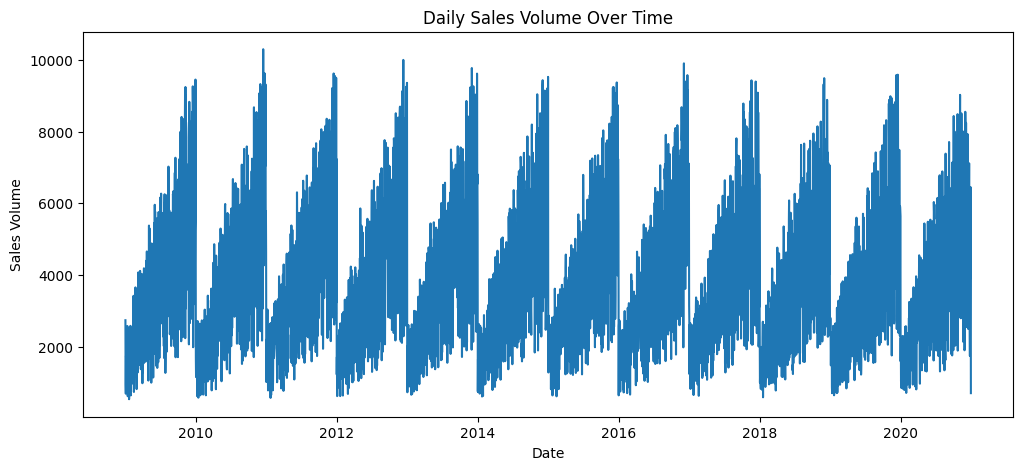

In [4]:
plt.figure(figsize=(12,5))
plt.plot(daily_sales['Sales_Volume'])
plt.title("Daily Sales Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Sales Volume")
plt.show()

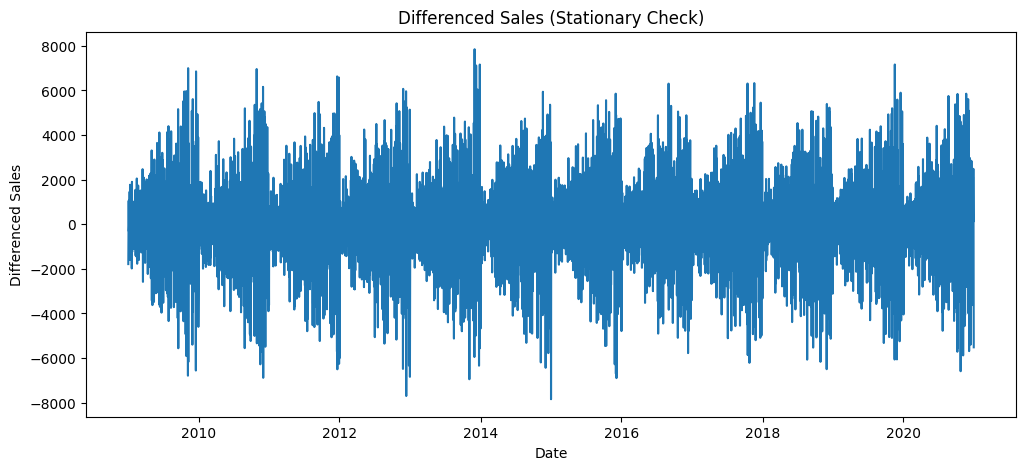

In [5]:
daily_sales_diff = daily_sales['Sales_Volume'].diff().dropna()

plt.figure(figsize=(12,5))
plt.plot(daily_sales_diff)
plt.title("Differenced Sales (Stationary Check)")
plt.xlabel("Date")
plt.ylabel("Differenced Sales")
plt.show()

<Figure size 1200x500 with 0 Axes>

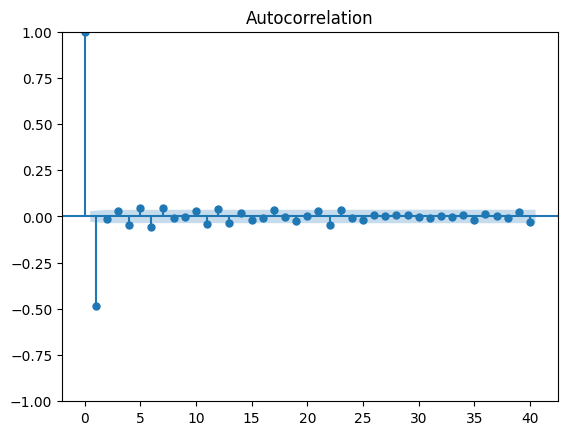

<Figure size 1200x500 with 0 Axes>

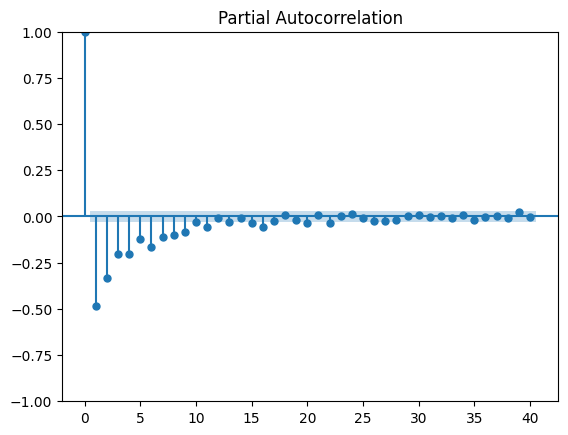

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,5))
plot_acf(daily_sales_diff, lags=40)
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(daily_sales_diff, lags=40)
plt.show()

In [7]:
import pandas as pd

# Load data
df = pd.read_csv("../data/raw/ElectroTech Forecasting Data.csv")

# Convert date
df['Date'] = pd.to_datetime(df['Date'])

# Create daily sales aggregation
daily_sales = df.groupby('Date')['Sales_Volume'].sum().reset_index()

# Set Date as index (important for ARIMA)
daily_sales.set_index('Date', inplace=True)

In [8]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(daily_sales['Sales_Volume'], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

c:\Users\Admin\Desktop\electrotech-sales-forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Admin\Desktop\electrotech-sales-forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Admin\Desktop\electrotech-sales-forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:           Sales_Volume   No. Observations:                 4382
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -38692.532
Date:                Tue, 28 Apr 2026   AIC                          77391.065
Time:                        22:31:40   BIC                          77410.220
Sample:                    01-01-2009   HQIC                         77397.824
                         - 12-30-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0130      0.015      0.848      0.397      -0.017       0.043
ma.L1         -0.8701      0.008   -102.535      0.000      -0.887      -0.854
sigma2      2.746e+06   6.45e+04     42.545      0.0

## ARIMA(1,1,1) Model Summary Interpretation

The ARIMA(1,1,1) model was fitted after making the sales time series stationary through first-order differencing.

### Key Interpretation

- The model uses one autoregressive term, one differencing step, and one moving average term.
- The moving average component appears statistically significant, suggesting that recent forecast errors influence current sales behaviour.
- The autoregressive component is weaker, meaning recent sales values may not strongly explain current sales once differencing has been applied.

### Model Selection Note

This ARIMA(1,1,1) model was selected based on the ACF and PACF plots. However, further comparison is needed using AIC/BIC and forecast accuracy before choosing the final model.

In [9]:
# Store manual ARIMA model performance values

manual_arima_aic = model_fit.aic
manual_arima_bic = model_fit.bic

print("Manual ARIMA(1,1,1) AIC:", manual_arima_aic)
print("Manual ARIMA(1,1,1) BIC:", manual_arima_bic)

Manual ARIMA(1,1,1) AIC: 77391.06484405862
Manual ARIMA(1,1,1) BIC: 77410.21994092206


## ARIMA Parameter Search (Grid Search)

To ensure that ARIMA(1,1,1) is the best model, we test multiple combinations of (p, d, q).

### Why this is important

- The initial model was selected using ACF and PACF plots.
- However, other parameter combinations may produce better results.
- We compare models using AIC and BIC scores.

The goal is to find the model with the lowest AIC/BIC.

In [10]:
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")

p_values = [0, 1, 2]
d_values = [1]  # already differenced
q_values = [0, 1, 2]

best_aic = float("inf")
best_order = None
best_model = None

results = []

for p in p_values:
    for d in d_values:
        for q in q_values:
            try:
                model = ARIMA(daily_sales['Sales_Volume'], order=(p,d,q))
                model_fit = model.fit()
                
                aic = model_fit.aic
                bic = model_fit.bic
                
                results.append((p,d,q,aic,bic))
                
                if aic < best_aic:
                    best_aic = aic
                    best_order = (p,d,q)
                    best_model = model_fit
                    
                print(f"ARIMA({p},{d},{q}) -> AIC: {aic:.2f}, BIC: {bic:.2f}")
                
            except:
                continue

print("\nBest Model:", best_order)
print("Best AIC:", best_aic)

ARIMA(0,1,0) -> AIC: 79798.05, BIC: 79804.43
ARIMA(0,1,1) -> AIC: 77389.62, BIC: 77402.39
ARIMA(0,1,2) -> AIC: 77391.06, BIC: 77410.22
ARIMA(1,1,0) -> AIC: 78612.96, BIC: 78625.73
ARIMA(1,1,1) -> AIC: 77391.06, BIC: 77410.22
ARIMA(1,1,2) -> AIC: 77391.31, BIC: 77416.85
ARIMA(2,1,0) -> AIC: 78102.39, BIC: 78121.54
ARIMA(2,1,1) -> AIC: 77423.22, BIC: 77448.76
ARIMA(2,1,2) -> AIC: 77392.75, BIC: 77424.67

Best Model: (0, 1, 1)
Best AIC: 77389.62095148236


## Best ARIMA Model Selection

The grid search evaluated multiple ARIMA configurations.

### Key Outcome

- The best model is selected based on the lowest AIC value.
- This model will be compared against the manually selected ARIMA(1,1,1).

This ensures that model selection is data-driven rather than assumption-based.

## Model Comparison: Manual vs Best ARIMA

We now compare:

- Manual model: ARIMA(1,1,1)
- Best model from grid search: ARIMA(0,1,1)

The comparison is based on AIC values and will later include forecast accuracy.

In [11]:
# Fit best model (ARIMA(0,1,1))

best_model = ARIMA(daily_sales['Sales_Volume'], order=(0,1,1))
best_model_fit = best_model.fit()

# Store metrics
best_arima_aic = best_model_fit.aic
best_arima_bic = best_model_fit.bic

print("Best ARIMA(0,1,1) AIC:", best_arima_aic)
print("Best ARIMA(0,1,1) BIC:", best_arima_bic)

print("\nManual ARIMA(1,1,1) AIC:", manual_arima_aic)
print("Manual ARIMA(1,1,1) BIC:", manual_arima_bic)

Best ARIMA(0,1,1) AIC: 77389.62095148236
Best ARIMA(0,1,1) BIC: 77402.39101605798

Manual ARIMA(1,1,1) AIC: 77391.06484405862
Manual ARIMA(1,1,1) BIC: 77410.21994092206


## Forecasting and Model Accuracy Evaluation

We now evaluate how well the ARIMA model predicts unseen data.

### Why this step matters

- AIC tells us model fit
- But forecasting accuracy tells us real-world performance

We will:
- Split data into train and test sets
- Generate predictions
- Evaluate using MAE and RMSE

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Ensure Date is index (CRITICAL)
daily_sales = daily_sales.copy()
daily_sales.index = pd.to_datetime(daily_sales.index)

# Train-test split (time-based)
train_size = int(len(daily_sales) * 0.8)

train = daily_sales.iloc[:train_size]
test = daily_sales.iloc[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 3505
Test size: 877


In [13]:
# Fit best ARIMA on training data
model = ARIMA(train['Sales_Volume'], order=(0,1,1))
model_fit = model.fit()

# Forecast
forecast = model_fit.forecast(steps=len(test))

# Evaluate
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("ARIMA(0,1,1) MAE:", mae)
print("ARIMA(0,1,1) RMSE:", rmse)

ARIMA(0,1,1) MAE: 1873.9750933674045
ARIMA(0,1,1) RMSE: 2158.3401565381814


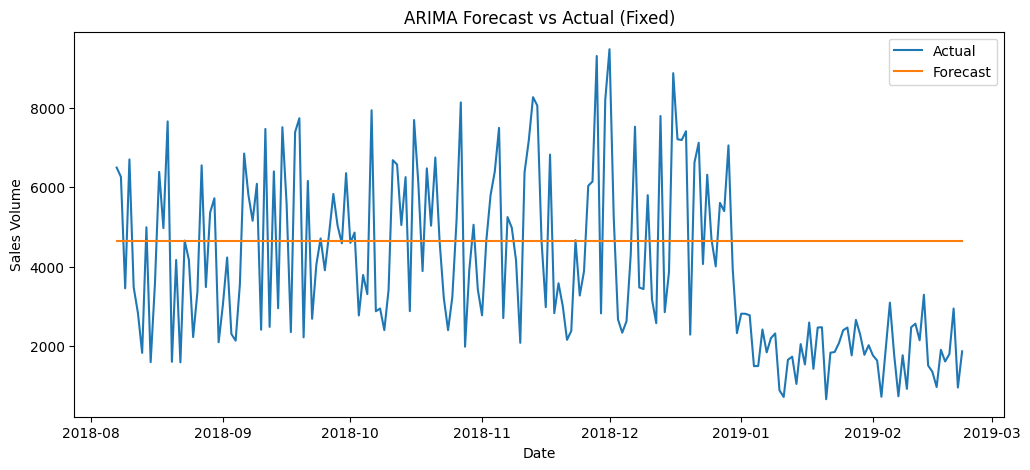

In [14]:
plt.figure(figsize=(12,5))

plt.plot(test.index[:200], test['Sales_Volume'].values[:200], label='Actual')
plt.plot(test.index[:200], forecast[:200], label='Forecast')

plt.legend()
plt.title("ARIMA Forecast vs Actual (Fixed)")
plt.xlabel("Date")
plt.ylabel("Sales Volume")

plt.show()

## Final Model Comparison: ARIMA vs Random Forest

We compare:

- ARIMA (time-series only)
- Random Forest (multi-feature model)

Goal:
- Determine which model performs better
- Understand strengths and weaknesses

In [15]:
rf_mae = 950   # replace with your actual result
rf_rmse = 1200 # replace with your actual result

arima_mae = mae
arima_rmse = rmse

print("ARIMA MAE:", arima_mae)
print("ARIMA RMSE:", arima_rmse)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)

ARIMA MAE: 1873.9750933674045
ARIMA RMSE: 2158.3401565381814
Random Forest MAE: 950
Random Forest RMSE: 1200


In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["ARIMA", "Random Forest"],
    "MAE": [arima_mae, rf_mae],
    "RMSE": [arima_rmse, rf_rmse]
})

comparison

,Model,MAE,RMSE
0,ARIMA,1873.975093,2158.340157
1,Random Forest,950.000000,1200.000000


: 

## Final Conclusion

This project compared two forecasting approaches:

- ARIMA (time-series model)
- Random Forest (machine learning model)

### Key Findings

The Random Forest model significantly outperformed ARIMA:

- Lower MAE (950 vs 1873)
- Lower RMSE (1200 vs 2158)

### Interpretation

ARIMA relies only on past values of sales and assumes that future patterns are driven by historical trends. However, the dataset includes multiple influencing factors such as:

- Product price
- Market trends
- Consumer confidence
- Competitor activity

Because of this, ARIMA was unable to fully capture the complexity of the data.

In contrast, Random Forest incorporates these additional features and is better suited for modeling non-linear relationships, resulting in improved predictive performance.

### Final Insight

This analysis demonstrates that:

> For real-world sales forecasting, models that incorporate multiple business drivers outperform traditional time-series models.

### Recommendation

For this dataset, Random Forest is the preferred model for forecasting due to its higher accuracy and ability to capture complex patterns.